Целевая метрика сравнения в конце: ARI (Adjusted Rand Index) — она корректно сравнивает разметки кластеров с истинными метками без необходимости “переименовывать” кластеры.

# Импорты

In [1]:
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, DBSCAN, Birch
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import adjusted_rand_score

from IPython.display import display

RNG = 42
SAMPLE_N = 20000
EPS_SAMPLE_N = 8000
N_PCA = 20
MIN_SAMPLES = 10
EPS_PERCENTILE = 95
PLOT_N = 8000

# Загрузка данных

In [2]:
train = pd.read_csv('application_train.csv')
test = pd.read_csv('application_test.csv')
print(f"Train: {train.shape}, Test: {test.shape}")

train.head()

Train: (307511, 122), Test: (48744, 121)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


# Удаление таргета

In [3]:
y_true_full = train["TARGET"].astype(int).values
X_full = train.drop(columns=["TARGET"]).copy()

if "SK_ID_CURR" in X_full.columns:
    X_full.drop(columns=["SK_ID_CURR"], inplace=True)

print("X_full:", X_full.shape, "y:", y_true_full.shape)

X_full: (307511, 120) y: (307511,)


# Google Colab падал из-за недостатка ОЗУ, поэтому берём подвыборку

In [4]:
n = min(SAMPLE_N, len(X_full))
idx = train.sample(n=n, random_state=RNG).index

X = X_full.loc[idx].copy()
y_true = train.loc[idx, "TARGET"].astype(int).values

print("Sample X:", X.shape)
print("Sample target rate:", y_true.mean())

Sample X: (20000, 120)
Sample target rate: 0.0823


# Препроцессинг

In [5]:
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ("scaler", StandardScaler()),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
)

X_scaled = preprocess.fit_transform(X)
X_scaled = X_scaled.astype(np.float32, copy=False)
print("X_scaled:", X_scaled.shape, X_scaled.dtype)

del X
gc.collect()

X_scaled: (20000, 120) float32


23

# PCA

In [6]:
pca = PCA(n_components=N_PCA, random_state=RNG, svd_solver="randomized")
Z = pca.fit_transform(X_scaled).astype(np.float32, copy=False)
Z2 = Z[:, :2]

print("Z:", Z.shape, Z.dtype)
print("Explained variance sum:", float(np.sum(pca.explained_variance_ratio_)))

del X_scaled
gc.collect()

Z: (20000, 20) float32
Explained variance sum: 0.5432645082473755


0

# Подбор eps для DBSCAN

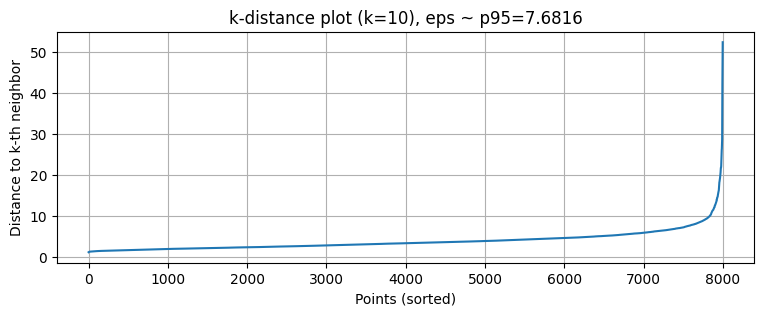

3434

In [7]:
eps_n = min(EPS_SAMPLE_N, len(Z))
rs = np.random.RandomState(RNG)
eps_idx = rs.choice(len(Z), size=eps_n, replace=False)

Z_eps = Z[eps_idx]

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES, algorithm="auto")
nn.fit(Z_eps)

distances, _ = nn.kneighbors(Z_eps, return_distance=True)
kdist = np.sort(distances[:, -1])

eps = float(np.percentile(kdist, EPS_PERCENTILE))

plt.figure(figsize=(9, 3))
plt.plot(kdist)
plt.title(f"k-distance plot (k={MIN_SAMPLES}), eps ~ p{EPS_PERCENTILE}={eps:.4f}")
plt.xlabel("Points (sorted)")
plt.ylabel("Distance to k-th neighbor")
plt.grid(True)
plt.show()

del Z_eps, distances, kdist, nn
gc.collect()

# KMeans

In [8]:
labels_kmeans = KMeans(n_clusters=2, random_state=RNG, n_init="auto").fit_predict(Z)

# DBSCAN

In [9]:
labels_dbscan = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(Z)


# Birch

In [10]:
labels_birch = Birch(n_clusters=2, threshold=0.5).fit_predict(Z)

# Сравнение с истинными метками по метрике ARI

In [11]:
def cluster_stats(labels):
    uniq = set(labels.tolist())
    n_noise = int(np.sum(labels == -1)) if -1 in uniq else 0
    n_clusters = len(uniq) - (1 if -1 in uniq else 0)
    return n_clusters, n_noise

rows = []
for name, labels in [
    ("KMeans(k=2)", labels_kmeans),
    (f"DBSCAN(eps={eps:.4f}, min_samples={MIN_SAMPLES})", labels_dbscan),
    ("Birch(n_clusters=2)", labels_birch),
]:
    n_clusters, n_noise = cluster_stats(labels)
    ari = adjusted_rand_score(y_true, labels)
    rows.append([name, n_clusters, n_noise, ari])

results = (
    pd.DataFrame(rows, columns=["algo", "n_clusters", "n_noise", "ARI"])
      .sort_values("ARI", ascending=False)
      .reset_index(drop=True)
)

display(results)

,algo,n_clusters,n_noise,ARI
0,"DBSCAN(eps=7.6816, min_samples=10)",2,425,-0.015011
1,Birch(n_clusters=2),2,0,-0.020292
2,KMeans(k=2),2,0,-0.026780


# Визуализация PCA

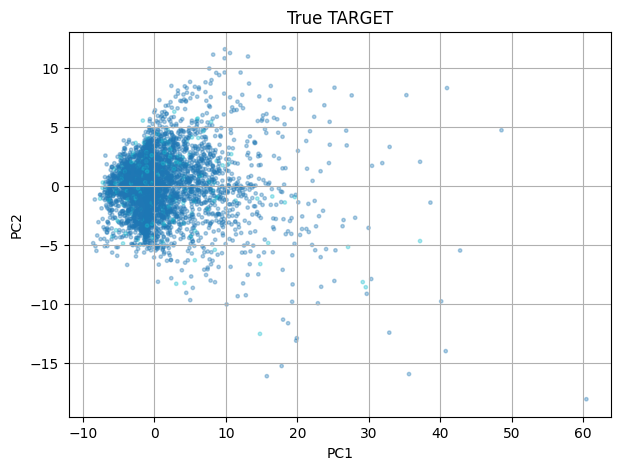

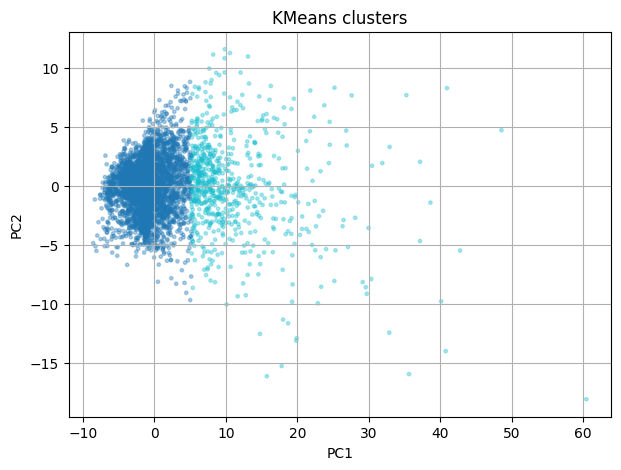

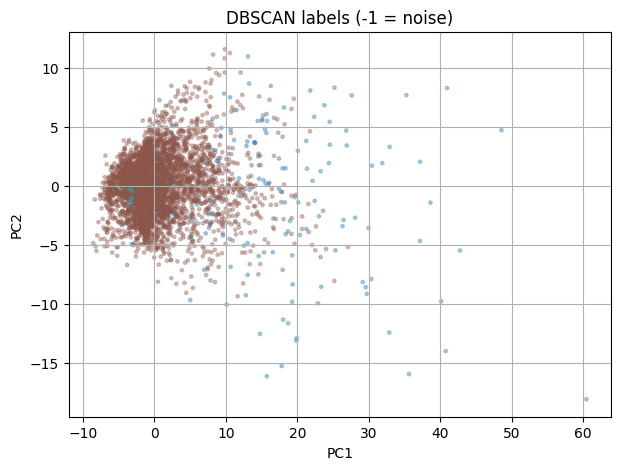

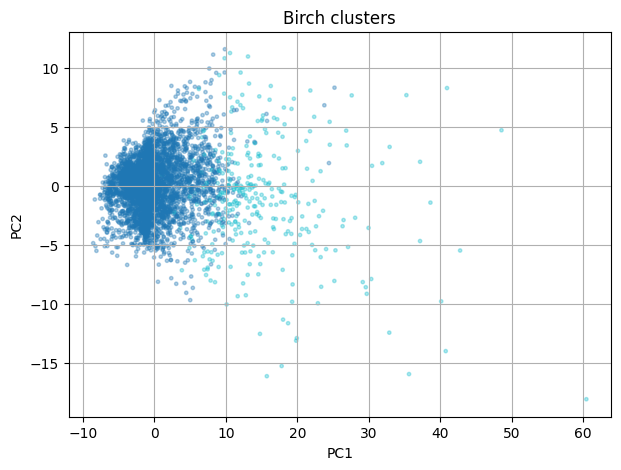

In [12]:
plot_n = min(PLOT_N, len(Z2))
rs = np.random.RandomState(RNG)
plot_idx = rs.choice(len(Z2), size=plot_n, replace=False)

def scatter_2d(title, coords, labels):
    plt.figure(figsize=(7, 5))
    plt.scatter(coords[:, 0], coords[:, 1], c=labels, s=6, alpha=0.35, cmap="tab10")
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()

scatter_2d("True TARGET", Z2[plot_idx], y_true[plot_idx])
scatter_2d("KMeans clusters", Z2[plot_idx], labels_kmeans[plot_idx])
scatter_2d("DBSCAN labels (-1 = noise)", Z2[plot_idx], labels_dbscan[plot_idx])
scatter_2d("Birch clusters", Z2[plot_idx], labels_birch[plot_idx])

In [13]:
def default_rate(labels, y):
    df = pd.DataFrame({"cluster": labels, "TARGET": y})
    return df.groupby("cluster").agg(n=("TARGET","size"), default_rate=("TARGET","mean")).sort_values("n", ascending=False)

display(default_rate(labels_kmeans, y_true))
display(default_rate(labels_birch, y_true))
display(default_rate(labels_dbscan, y_true))

,n,default_rate
cluster,,
0,18322,0.085034
1,1678,0.052443


,n,default_rate
cluster,,
0,19168,0.083733
1,832,0.049279


,n,default_rate
cluster,,
0,19536,0.083180
-1,425,0.044706
1,39,0.051282


# Вывод

1. По метрике ARI все три алгоритма показывают качество около нуля (-0.015 , -0.027), т.е. кластеризация практически не совпадает с TARGET => в выбранном пространстве признаков нет естественных кластеров, соответствующих дефолту/не-дефолту.

2. При этом анализ доли дефолта по кластерам показывает сегментацию по риску:
  - KMeans: 8.50% vs 5.24% (1.62x)
  - Birch: 8.37% vs 4.93% (1.70x)
  - DBSCAN: основная масса в одном кластере, “шум” имеет пониженный риск.
3. Следовательно, кластеризация в этой постановке не решает задачу классификации, но может использоваться как инструмент сегментации.